### Шаг 0: Импорты и настройка

In [1]:
import os
import sys

notebook_dir = os.getcwd()
if notebook_dir not in sys.path:
    sys.path.append(notebook_dir)

In [2]:
import torch
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
from pytorch_lightning.callbacks import EarlyStopping
import numpy as np
import random
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gensim.downloader as api
from pytorch_lightning.loggers import CSVLogger
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
pl.seed_everything(42)

print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


W0618 15:53:24.761000 16216 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


PyTorch version: 2.13.0.dev20260602+cu130
PyTorch Lightning version: 2.6.5
CUDA available: True


### Шаг 2: Загружаем датасет, делим на тренировочные и тестовые данные
 Функции находятся в `src_0/data.py`

In [3]:
from src_0.data import get_data
dataset, train_texts, val_texts, train_labels, val_labels, test_texts, test_labels, class_names = get_data()

Loading AG News dataset...



Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Train set size: 120000
Test set size: 7600

After split:
Train: 108000
Val: 12000
Test: 7600

Classes: ['World', 'Sports', 'Business', 'Sci/Tech']


In [4]:
print(dataset['train'][2])

{'text': "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.", 'label': 2}


### Шаг 3: Формируем словари
функция находится в `src_0_0_0/data`

In [5]:
from src_0.data import make_token_dict

vocab, idx_to_word = make_token_dict(train_texts)
#vocab, idx_to_word, top_30_pairs = make_token_dict(train_texts)

Building vocabulary...
Total unique words: 80619
Words with freq >= 2: 49665

Vocabulary size: 30000
Top 10 words: ['<pad>', '<unk>', 'the', 'to', 'a', 'of', 'in', 'and', 'on', 'for']


### Шаг 4: Загружаем модель FastText и создаем таблицу эмбеддингов

In [6]:
from gensim.models import KeyedVectors

LOCAL_MODEL_PATH = "fasttext_fast_local.wordvectors"

if not os.path.exists(LOCAL_MODEL_PATH):
    fast_model = api.load("fasttext-wiki-news-subwords-300")
    fast_model.save("fasttext_fast_local.wordvectors")

else:
    fast_model = KeyedVectors.load("fasttext_fast_local.wordvectors")


В файле `src_0/FastText.py` находится кастомный класс конструктора таблицы эмбеддингов, использующий за основу модель FastText.

In [7]:
from src_0.FastText import MyEmbedTable

embed_table_builder = MyEmbedTable(vocab, fast_model)
embeddings = embed_table_builder.make_emb_layer()

### Шаг 5: Dataset класс с динамическим паддингом
находится в `src_0/data`

In [8]:
from src_0.data import AGNewsDataset

max_len = 128
train_dataset = AGNewsDataset(train_texts, train_labels, vocab, max_len=max_len)
val_dataset = AGNewsDataset(val_texts, val_labels, vocab, max_len=max_len)
test_dataset = AGNewsDataset(test_texts, test_labels, vocab, max_len=max_len)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

sample_text, sample_label = train_dataset[0]
print(f"\nSample:")
print(f"  Text length: {len(sample_text)}")
print(f"  Label: {sample_label.item()} ({class_names[sample_label.item()]})")

Train dataset size: 108000
Val dataset size: 12000
Test dataset size: 7600

Sample:
  Text length: 53
  Label: 1 (Sports)


### Шаг 6: DataLoaders
Создаём DataLoaders с batch_size=128 и collate_fn для динамического паддинга.

In [9]:
from src_0.data import collate_fn
from config import BATCH_SIZE

batch_size = BATCH_SIZE

train_loader = DataLoader(train_dataset,
    batch_size=batch_size,
    shuffle=True, 
    num_workers=0, 
    collate_fn=collate_fn)

val_loader = DataLoader(val_dataset, 
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn)

test_loader = DataLoader(test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

sample_batch = next(iter(train_loader))
x, mask, y = sample_batch
print(f"\nSample batch:")
print(f"  Text shape: {x.shape}")
print(f"  Mask shape: {mask.shape}")
print(f"  Labels shape: {y.shape}")

Train batches: 1688
Val batches: 188
Test batches: 119

Sample batch:
  Text shape: torch.Size([64, 65])
  Mask shape: torch.Size([64, 65])
  Labels shape: torch.Size([64])


### Шаг 7: Обучение
* Иcпользуем модель BiLSTM
* в модели используем эмбеддинги, ранее инициализированные с помощью FastText
* замораживаем эмбеддинги `freeze_embeddings=True` во избежание переобучения модели

In [10]:
from src_0.lightning_module import BiLSTMModule
max_epochs = 20

vocab_size = len(vocab)
freeze_embeddings = True

early_stop_callback = EarlyStopping(
    monitor="val_f1",
    min_delta=0.001,
    mode='max',
    patience=5,
    verbose=True
)

csv_logger = CSVLogger(
    save_dir="logs/",
    name="bilstm_fasttext")

model = BiLSTMModule(
    vocab_size=vocab_size, 
    embed_dim=embed_table_builder.embed_dim, 
    hidden_dim=128,
    num_layers=1,
    num_classes=4, 
    dropout=0.5,
    lr=1e-3,
    embedding_matrix=embeddings,
    freeze_embeddings=freeze_embeddings
)

trainer = pl.Trainer(
    max_epochs=max_epochs,
    logger=csv_logger,
    accelerator='auto',
    devices=1,
    enable_progress_bar=False,
    log_every_n_steps=50,
    gradient_clip_val=1.0,
    callbacks=[early_stop_callback]
)

print("Starting training...")
print(f"Freeze embeddings: {freeze_embeddings}")
start_time = time.time()
trainer.fit(model, train_loader, val_loader)
total_time = time.time() - start_time

bilstm_w2v_epoch_time = total_time / 5

print(f"\nTraining completed in {total_time:.2f} seconds")
print(f"Average time per epoch: {bilstm_w2v_epoch_time:.2f} seconds")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 5060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


Starting training...
Freeze embeddings: True


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BiLSTM             │  9.4 M │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 443 K                                                                                            
Non-trainable params: 9.0 M                                                                                        
Total params: 9.4 M                                                                                                
Total estimated model params size (MB): 37.774                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
Metric val_f1 improved. New best score: 0.901
Metric val_f1 improved by 0.012 >= min_delta = 0.001. New best score: 0.913
Metric val_f1 improved by 0.009 >= min_delta = 0.001. New best score: 0.922
Metric val_f1 improved by 0.002 >= min_delta = 0.001. New best score: 0.923
Metric val_f1 improved by 0.002 >= min_delta = 0.001. New best score: 0.925
Monitored metric val_f1 did not improve in the last 5 records. Best score: 0.925. Signaling Trainer to stop.



Training completed in 300.47 seconds
Average time per epoch: 60.09 seconds


In [11]:
import winsound
for i in range(3, 8):
    winsound.Beep(i*100, 200)

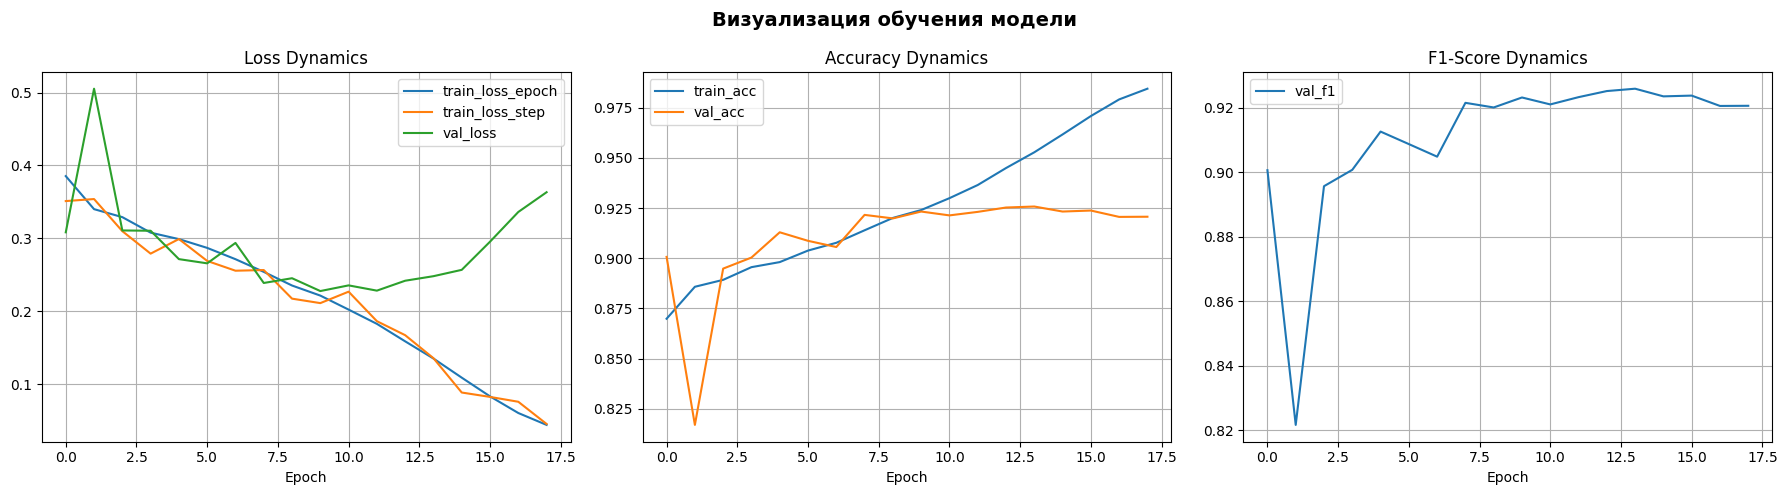

In [12]:
df = pd.read_csv(f"{csv_logger.log_dir}/metrics.csv").groupby("epoch").mean()

loss_cols = [c for c in df.columns if "loss" in c]
acc_cols = [c for c in df.columns if "acc" in c]
f1_cols = [c for c in df.columns if "f1" in c]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Визуализация обучения модели", fontsize=14, fontweight="bold")

if loss_cols:
    df[loss_cols].plot(ax=axes[0], grid=True, title="Loss Dynamics")
    axes[0].set_xlabel("Epoch")

if acc_cols:
    df[acc_cols].plot(ax=axes[1], grid=True, title="Accuracy Dynamics")
    axes[1].set_xlabel("Epoch")
else:
    axes[1].text(0.5, 0.5, "Accuracy not found", ha="center")

if f1_cols:
    df[f1_cols].plot(ax=axes[2], grid=True, title="F1-Score Dynamics")
    axes[2].set_xlabel("Epoch")
else:
    axes[2].text(0.5, 0.5, "F1-Score not found", ha="center")

plt.tight_layout()
plt.show()

### Шаг 8: Оценка на тесте

In [13]:
test_acc = MulticlassAccuracy(num_classes=4)
test_f1 = MulticlassF1Score(num_classes=4, average='macro')

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        x, mask, y = batch
        logits = model(x, mask)
        preds = torch.argmax(logits, dim=1)
        
        test_acc(logits, y)
        test_f1(logits, y)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

bilstm_w2v_test_acc = test_acc.compute().item()
bilstm_w2v_test_f1 = test_f1.compute().item()

print(f"Test Accuracy: {bilstm_w2v_test_acc:.4f}")
print(f"Test Macro F1: {bilstm_w2v_test_f1:.4f}")


Test Accuracy: 0.9218
Test Macro F1: 0.9218


### Confusion Matrix

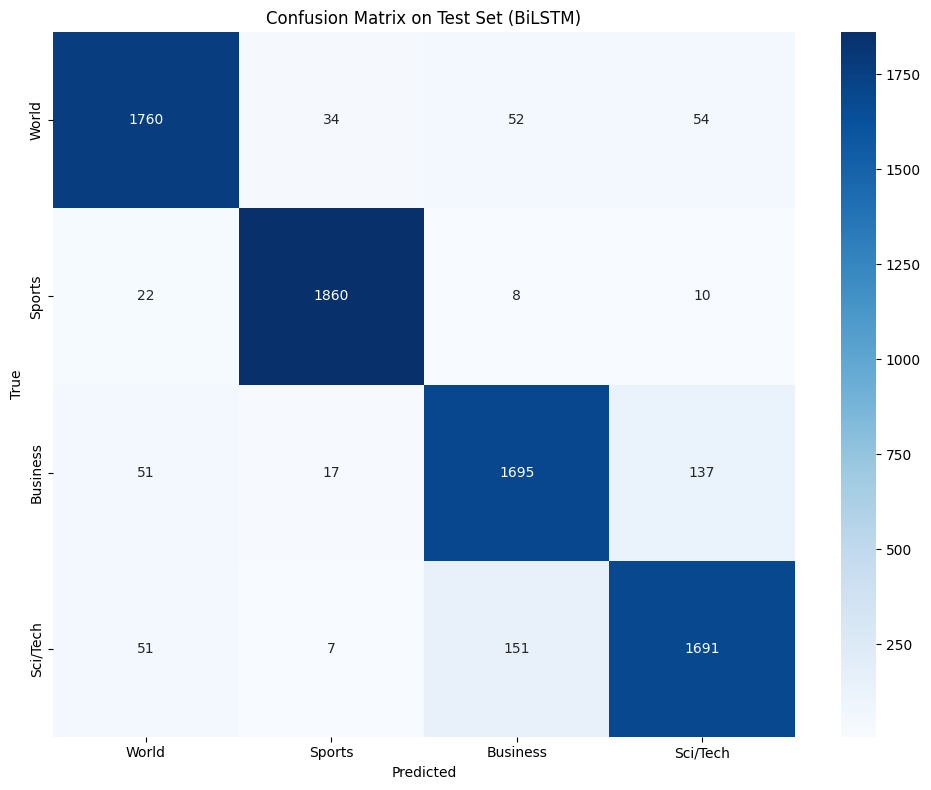

World: Precision=0.934, Recall=0.926, F1=0.930
Sports: Precision=0.970, Recall=0.979, F1=0.974
Business: Precision=0.889, Recall=0.892, F1=0.891
Sci/Tech: Precision=0.894, Recall=0.890, F1=0.892


In [14]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Test Set (BiLSTM)')
plt.tight_layout()
plt.show()

for i, class_name in enumerate(class_names):
    precision = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
    recall = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"{class_name}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")


### Анализ ошибок

In [15]:
errors = []
for i, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):
    if true_label != pred_label:
        errors.append((i, true_label, pred_label))

print(f"Total errors: {len(errors)} out of {len(all_labels)} ({len(errors)/len(all_labels)*100:.2f}%)")
print("\n5 Typical Errors:\n")

for idx, (i, true_label, pred_label) in enumerate(errors[:5]):
    text = test_texts[i]
    print(f"Error {idx+1}:")
    print(f"  True: {class_names[true_label]} ({true_label})")
    print(f"  Pred: {class_names[pred_label]} ({pred_label})")
    print(f"  Text: {text[:200]}...")
    print()


Total errors: 594 out of 7600 (7.82%)

5 Typical Errors:

Error 1:
  True: Business (2)
  Pred: World (0)
  Text: Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul....

Error 2:
  True: Sci/Tech (3)
  Pred: Business (2)
  Text: Teenage T. rex's monster growth Tyrannosaurus rex achieved its massive size due to an enormous growth spurt during its adolescent years....

Error 3:
  True: Sci/Tech (3)
  Pred: Business (2)
  Text: IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount since 1991....

Error 4:
  True: Sci/Tech (3)
  Pred: Business (2)
  Text: Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bi...

Error 5:
  True: Sci/Tech (3)
  Pred: Business (2)
  Text: Rivals T